<a href="https://colab.research.google.com/github/nithinrb/Emotion-analyzer/blob/main/DAY2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

R2 Score: 0.5542632452871117
MSE: 3418946311.180807
Predicted Price: 229877.66599078485


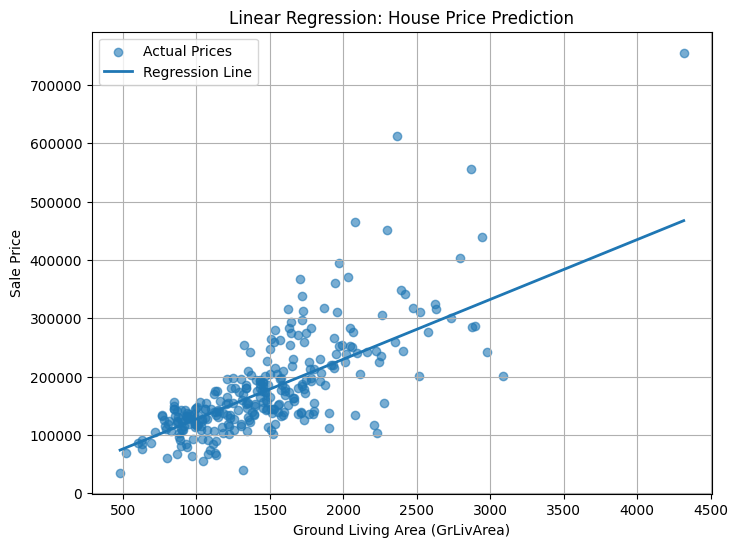

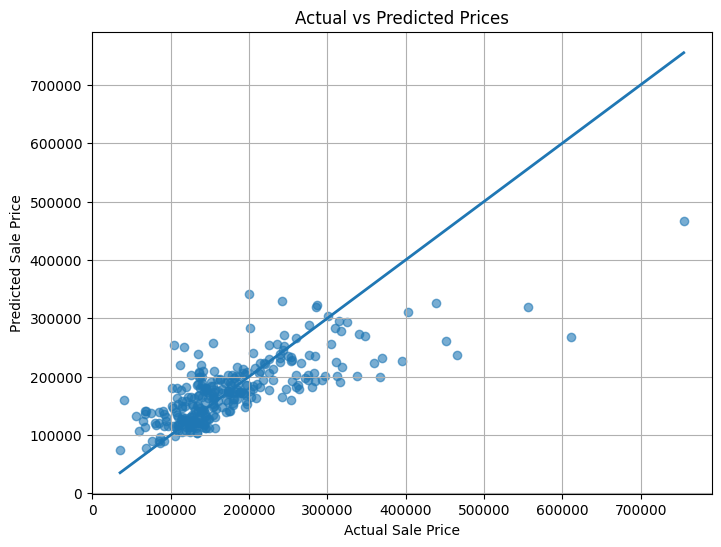

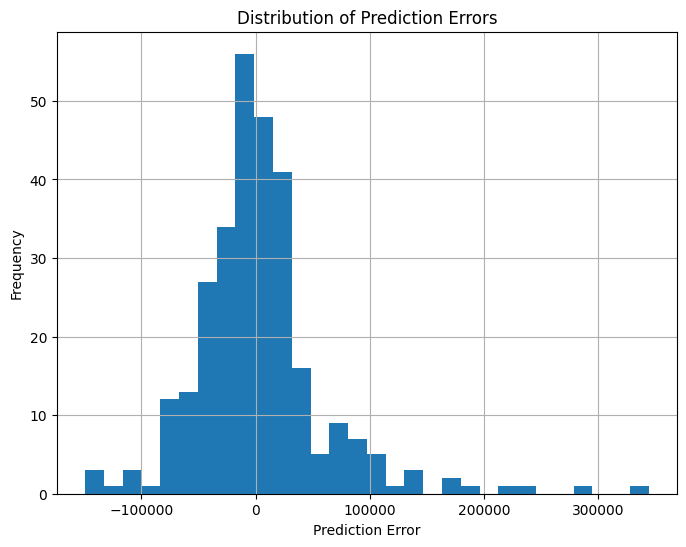

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# =========================
# Load Dataset
# =========================
data = pd.read_csv('/content/train.csv')

# Select feature and target
X = data[['GrLivArea']]
y = data['SalePrice']

# =========================
# Split Dataset
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# =========================
# Train Model
# =========================
model = LinearRegression()
model.fit(X_train, y_train)

# =========================
# Predictions
# =========================
y_pred = model.predict(X_test)

# =========================
# Evaluation
# =========================
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2 Score:", r2)
print("MSE:", mse)

# =========================
# Predict New House
# =========================
new_house = pd.DataFrame({
    'GrLivArea': [2000]
})

predicted_price = model.predict(new_house)

print("Predicted Price:", predicted_price[0])

# =========================
# Visualization 1:
# Scatter Plot + Regression Line
# =========================
plt.figure(figsize=(8, 6))

plt.scatter(
    X_test,
    y_test,
    alpha=0.6,
    label='Actual Prices'
)

sorted_idx = X_test['GrLivArea'].argsort()

plt.plot(
    X_test.iloc[sorted_idx],
    y_pred[sorted_idx],
    linewidth=2,
    label='Regression Line'
)

plt.xlabel('Ground Living Area (GrLivArea)')
plt.ylabel('Sale Price')
plt.title('Linear Regression: House Price Prediction')
plt.legend()
plt.grid(True)

plt.show()

# =========================
# Visualization 2:
# Actual vs Predicted
# =========================
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linewidth=2
)

plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('Actual vs Predicted Prices')
plt.grid(True)

plt.show()

# =========================
# Visualization 3:
# Error Distribution
# =========================
errors = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.hist(errors, bins=30)

plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')
plt.grid(True)

plt.show()

Accuracy: 0.7374301675977654

Confusion Matrix:
[[93 12]
 [35 39]]

Passenger Survived


<Figure size 600x500 with 0 Axes>

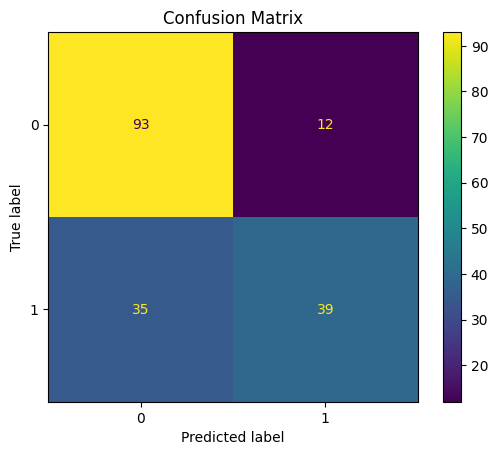

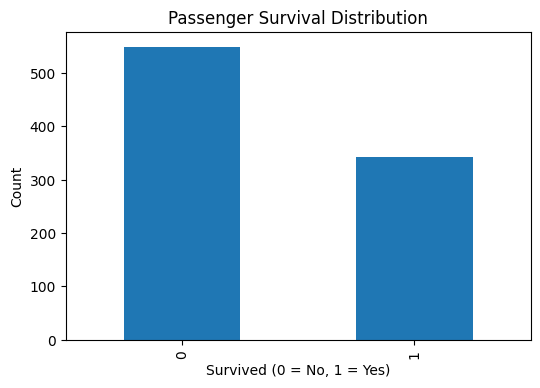

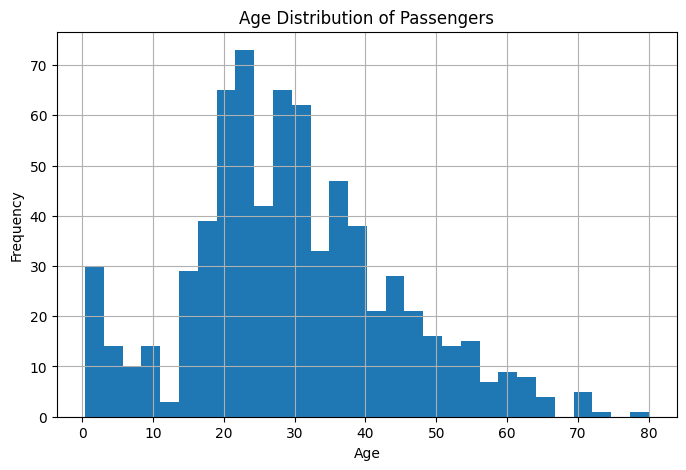

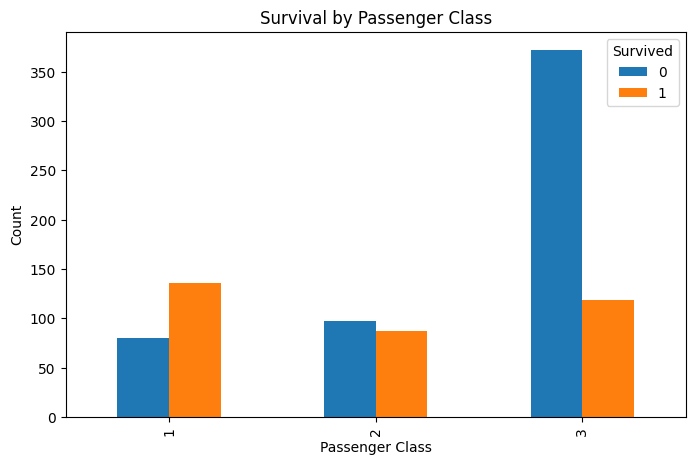

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ==========================
# Load Dataset
# ==========================
data = pd.read_csv('/content/titanic_data.csv')

# ==========================
# Data Preprocessing
# ==========================
X = data[['Pclass', 'Age', 'Fare']].copy()

# Fill missing Age values
X['Age'] = X['Age'].fillna(X['Age'].mean())

# Target variable
y = data['Survived']

# ==========================
# Split Dataset
# ==========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================
# Train Model
# ==========================
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# ==========================
# Predictions
# ==========================
y_pred = model.predict(X_test)

# ==========================
# Accuracy
# ==========================
print("Accuracy:", accuracy_score(y_test, y_pred))

# ==========================
# Confusion Matrix
# ==========================
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ==========================
# New Passenger Prediction
# ==========================
new_passenger = pd.DataFrame({
    'Pclass': [1],
    'Age': [30],
    'Fare': [80]
})

prediction = model.predict(new_passenger)

if prediction[0] == 1:
    print("\nPassenger Survived")
else:
    print("\nPassenger Did Not Survive")

# ==========================
# Visualization 1
# Confusion Matrix Plot
# ==========================
plt.figure(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

# ==========================
# Visualization 2
# Survival Distribution
# ==========================
plt.figure(figsize=(6,4))
data['Survived'].value_counts().plot(kind='bar')

plt.title("Passenger Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()

# ==========================
# Visualization 3
# Age Distribution
# ==========================
plt.figure(figsize=(8,5))

data['Age'].hist(bins=30)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

# ==========================
# Visualization 4
# Survival by Passenger Class
# ==========================
survival_by_class = pd.crosstab(
    data['Pclass'],
    data['Survived']
)

survival_by_class.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")

plt.show()

Accuracy: 0.9015

Confusion Matrix:
[[ 488  113]
 [  84 1315]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       601
           1       0.92      0.94      0.93      1399

    accuracy                           0.90      2000
   macro avg       0.89      0.88      0.88      2000
weighted avg       0.90      0.90      0.90      2000



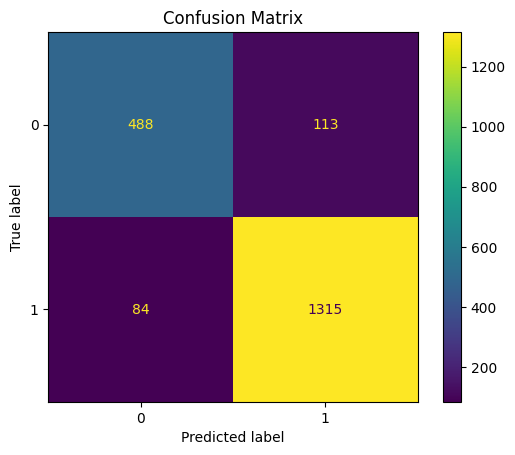

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Load dataset
data = pd.read_excel('student_marks_10000 (1).xlsx')

# Features
X = data[['Study_Hours', 'Attendance', 'Assignment_Score']]

# Convert Pass/Fail to numeric
y = data['Result'].map({'Fail': 0, 'Pass': 1})

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualization
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

Accuracy: 0.9015

Confusion Matrix:
[[ 488  113]
 [  84 1315]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       601
           1       0.92      0.94      0.93      1399

    accuracy                           0.90      2000
   macro avg       0.89      0.88      0.88      2000
weighted avg       0.90      0.90      0.90      2000



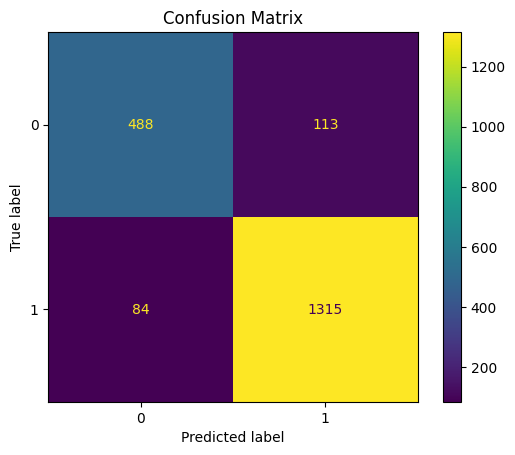

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Load dataset
data = pd.read_excel('student_marks_10000 (1).xlsx')

# Features
X = data[['Study_Hours', 'Attendance', 'Assignment_Score']]

# Convert Pass/Fail to numeric
y = data['Result'].map({'Fail': 0, 'Pass': 1})

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualization
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

===== REGRESSION RESULTS =====
Mean Squared Error: 24.92245623377605
R2 Score: 0.8565784063748548


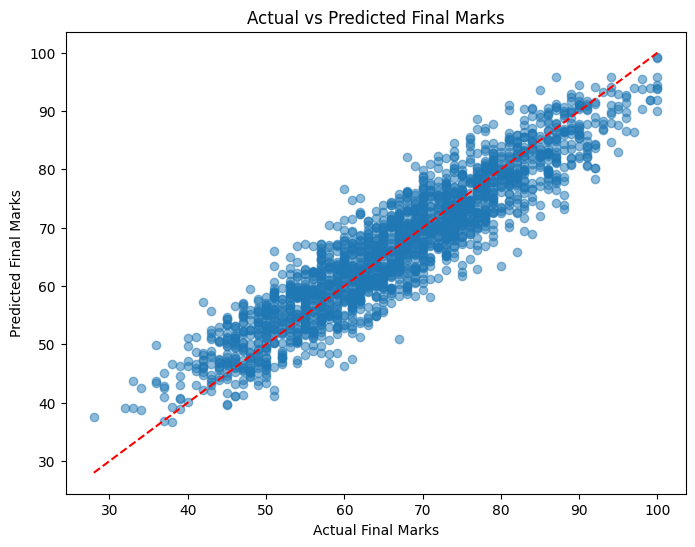


===== CLASSIFICATION RESULTS =====
Accuracy: 0.9015

Classification Report:
              precision    recall  f1-score   support

        Fail       0.85      0.81      0.83       601
        Pass       0.92      0.94      0.93      1399

    accuracy                           0.90      2000
   macro avg       0.89      0.88      0.88      2000
weighted avg       0.90      0.90      0.90      2000


Confusion Matrix:
[[ 488  113]
 [  84 1315]]


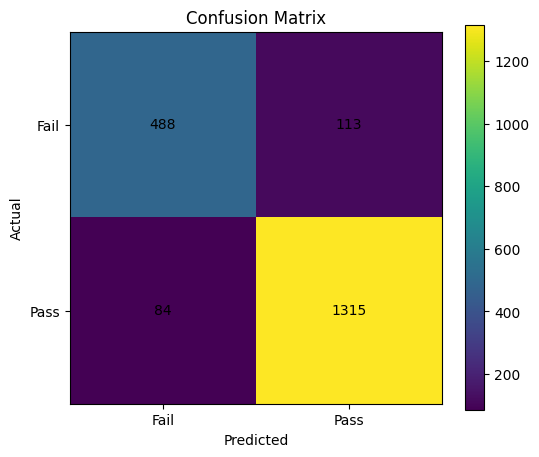

In [28]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Load dataset
data = pd.read_excel("/content/student_marks_10000 (1).xlsx")

# -----------------------------
# REGRESSION: Predict Final Marks
# -----------------------------

X = data[['Study_Hours', 'Attendance', 'Assignment_Score']]
y = data['Final_Marks']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Linear Regression model
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

# Predictions
y_pred = reg_model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("===== REGRESSION RESULTS =====")
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

# Visualization
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Final Marks")
plt.ylabel("Predicted Final Marks")
plt.title("Actual vs Predicted Final Marks")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.show()


# -----------------------------
# CLASSIFICATION: Pass / Fail
# -----------------------------

X_cls = data[['Study_Hours', 'Attendance', 'Assignment_Score']]
y_cls = data['Result']

# Split data
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

# Train Logistic Regression model
clf_model = LogisticRegression(max_iter=1000)
clf_model.fit(X_train_cls, y_train_cls)

# Predictions
y_pred_cls = clf_model.predict(X_test_cls)

# Evaluation
accuracy = accuracy_score(y_test_cls, y_pred_cls)

print("\n===== CLASSIFICATION RESULTS =====")
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test_cls, y_pred_cls))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_cls, y_pred_cls))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test_cls, y_pred_cls)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.colorbar()
plt.xticks([0,1], ['Fail','Pass'])
plt.yticks([0,1], ['Fail','Pass'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i, j],
                 ha='center', va='center')

plt.show()